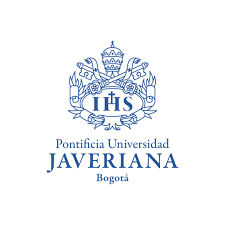
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**


Autor: J. Corredor (Aqui Nombre y Apellido de Autor (Uds.)

Fecha de Inicio: 

Fecha actual: 


## **Apache Spark**

- Spark es un *FrameWork* para Big Data que incluye *bibliotecas* para el análisis de datos, el aprendizaje automático, el análisis de grafos y el procesamiento de datos en tiempo real. 
- Spark se presenta mucho más rápido dado que escribe los resultados/objetos intermedios en memoria principal siempre que sea posible.
- El ecosistema de Hadoop incluye un sistema de almacenamiento de archivos distribuido llamado HDFS (Hadoop Distributed File System). 
- Spark, por su parte, no incluye un sistema de almacenamiento de archivos. 
- Se puede utilizar Spark sobre HDFS, o de otras fuentes (locales o en la nube).
- Spark no es un lenguaje de programación como Python o Java. Se trata de un motor de procesamiento de datos distribuido de uso general, adecuado para su aplicación en una amplia variedad de situaciones. Resulta especialmente útil para el procesamiento de big data, tanto a gran escala como a alta velocidad.
- Los desarrolladores de aplicaciones y los científicos de datos suelen incorporar Spark en sus aplicaciones para consultar, analizar y transformar datos rápidamente y a gran escala.
- Algunas de las tareas que se asocian con mayor frecuencia a Spark incluyen:
        – Trabajos por lotes de ETL y SQL en grandes conjuntos de datos (a menudo de terabytes de tamaño).
        – Procesamiento de datos en streaming procedentes de dispositivos y nodos de IoT, datos de diversos sensores, sistemas financieros y transaccionales de todo tipo.
        – Tareas de aprendizaje automático para aplicaciones de comercio electrónico o de TI.

- En esencia, Spark se basa en el marco Hadoop/HDFS para gestionar archivos distribuidos. Se implementa principalmente con Scala, una variante del lenguaje funcional de Java.
- Existen bibliotecas desarrolladas para el análisis de consultas de tipo SQL, el aprendizaje automático distribuido, el cálculo de grafos a gran escala y el procesamiento de datos en streaming, que se pueden acceder desde SPARK.
- Spark admite múltiples lenguajes de programación en forma de bibliotecas de interfaz fáciles de usar: Java, Python, Scala y R.

## **Funcionamiento**

- La idea básica del procesamiento distribuido consiste en dividir los bloques de datos en pequeñas partes manejables (lo que incluye ciertos procesos de filtrado y ordenación), acercar el cálculo a los datos —es decir, utilizar pequeños nodos de un gran clúster para tareas específicas— y, a continuación, volver a combinarlos.

- La parte de división se denomina acción «Map» y la recombinación se denomina acción «Reduce». Juntas, conforman el famoso paradigma «MapReduce», que fue introducido por Google alrededor de 2004.

- Por ejemplo, si un archivo tiene 100 registros que procesar, 100 mappers pueden ejecutarse a la vez para procesar un registro cada uno. O tal vez 50 mapeadores pueden ejecutarse juntos para procesar dos registros cada uno. Una vez que todos los mapeadores han completado el procesamiento, el marco baraja y ordena los resultados antes de pasarlos a los reductores. Un reductor no puede iniciarse mientras un mapeador aún está en curso.

- Todos los valores de salida del mapeo que tienen la misma clave se asignan a un único reductor, que a continuación agrega los valores para esa clave.

## **RDD**

- RDD son las siglas de «Resilient Distributed Dataset» (conjunto de datos distribuido y resistente); se trata de elementos que se ejecutan y operan en varios nodos para realizar un procesamiento paralelo en un clúster.
- Los RDD son elementos inmutables, lo que significa que, una vez creado un RDD, no se puede modificar.
- Los RDD también son tolerantes a fallos, por lo que, en caso de producirse algún fallo, se recuperan automáticamente.
- Se pueden aplicar múltiples operaciones a estos RDD para llevar a cabo una tarea determinada.
- Para aplicar operaciones a estos RDD, hay dos formas:
        –  Transformación: son las operaciones que se aplican a un RDD para crear un nuevo RDD. Filter, groupBy y map son ejemplos de transformaciones.
        – Acción: son las operaciones que se aplican a un RDD y que indican a Spark que realice el cálculo y envíe el resultado al controlador.


## **Objetivos**

- 1.- Importar bibliotecas necesarias
- 2.- Crear una sesión con SPARK
- 3.- Interactuar con RDD
- 4.- Operaciones sobre los RDD's
- 5.- Creación de Funciones Definidas por el Usuario (UDF)
- 6.- Interacción con Hadoop HDFS
- 7.- Carga de CSV desde Hadoop HDFS hacia Spark
- 8.- Aplicaciones de funciones varias: map, parallelize y lambda
- 9.- Objetos DataFrame en Spark
    * Creación de DataFrame manualmente
    * Lectura de DF
    * Escritura de DF
    * Validar DF
    * Búsquedas en DF
    * Selección de funcionalidad sobre un DF
    * Filtrar DF
    * Dividir DF

- 10.- Introducing SQL in PySpark

### **1.- Importar Bibliotecas**

In [ ]:
###-->

import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

###-->
import findspark
findspark.init("/mnt/sda1/Cluster/Spark")
from pylab import *
import pyspark.sql.functions as F
from pyspark import SparkConf, SparkContext
from pyspark.sql import SQLContext
from pyspark.sql import SparkSession
from pyspark.sql.types import *

### **2.- Creación de Sesión de Trabajo SPARK y Contexto SPARK**

In [ ]:
###--> Creación de sesión SPARK
configura = SparkConf()

###--> Se crea la configuración
configura.setAppName("Spark_Franco_00")

###--> Se crea la SESIÓN en función de la configuración (Spark+Apellido del autor)
sparkFranco = SparkSession.builder.config(conf=configura).getOrCreate()

###-->
SQLContext(sparkContext=sparkFranco.sparkContext, sparkSession=sparkFranco)

###-->
sparkContextoFranco = sparkFranco.sparkContext.getOrCreate()

###-->
print("\nSesion creada: Laboratorio 01\n")

###-->
sparkFranco

### **3.- Interacción sobre RDD de Spark**

In [ ]:
###--> 3.1.- Creación de un RDD vacio

rdd = sparkContextoFranco.emptyRDD()
rdd.isEmpty()

In [ ]:
###-->

a = sparkContextoFranco.parallelize([])
a.isEmpty()

In [ ]:
###--> 3.3.- Se crea un RDD con particiones manualmente
mixRDD = sparkContextoFranco.parallelize([True, [11,22,33,44,55], (10,20,30,40,50)], 3)
mixRDD.collect()

In [ ]:
###--> 3.4.- Se revisa el número de particiones

mixRDD.getNumPartitions()

In [ ]:
###--> 3.5.- Se recopila los datos con particiones

mixRDD.glom().collect()

In [ ]:
###-->

mixRDD.setName('Mi_RDD')

In [ ]:
###--> Usando Rangos para crear RDD

a= sparkContextoFranco.parallelize(range(1,4000), 4)
print(a.getNumPartitions())
print("\n")
print(a.glom().take(1)) ###-->
print("\n")
print(a.glom().max()) 
print("\n")
print(a.glom().min()) #
print("\n")

In [ ]:
###--> Se ordenan y re-reparten RDD

###--> Uso de función lambda o función anónima para ordenar

b = sparkContextoFranco.parallelize([12,21,23,43,1,22,11,45,56])
b.takeOrdered(4, key=lambda x: -x)

In [ ]:
###--> Coalescence, reparticiones y debug (DAG)

c = sparkContextoFrao.parallelize(range(1,1000), 5)
###--> 
c.getNumPartitions()

In [ ]:
###-->
d = c.repartition(7)
d.getNumPartitions()

###-->
w = c.repartition(4)
w.getNumPartitions()

In [ ]:
###-->
w.coalesce(6)
w.getNumPartitions()

###-->
w.coalesce(2)
w.getNumPartitions()

Referencia: <a href="https://www.databricks.com/blog/2015/06/22/understanding-your-spark-application-through-visualization.html">DAG en DataBricks</a>

In [ ]:
###-->

w.toDebugString()

### - **4.- Operaciones sobre los RDD's**

- #### **Transformación**

* Las transformaciones son un tipo de operaciones que transforman los datos de un RDD de una forma a otra. Al aplicar esta operación a cualquier RDD, se obtiene un nuevo RDD con los datos transformados (los RDD en Spark son inmutables). Operaciones como map, filter y flatMap son transformaciones.

* Cuando se aplica la transformación a cualquier RDD, la operación no se ejecuta de inmediato. Se creará un DAG (grafo acíclico dirigido) utilizando la operación aplicada, el RDD de origen y la función utilizada para la transformación. Y seguirá construyendo este grafo utilizando las referencias hasta que se aplique cualquier operación de acción al último RDD de la fila. Por eso las transformaciones en Spark son *perezosas*. Spark dispone de ciertas operaciones que se pueden realizar sobre un RDD. Una operación es un método que se puede aplicar a un RDD para llevar a cabo una tarea determinada. Los RDD admiten dos tipos de operaciones: acciones y transformaciones. Una **operación** puede ser algo tan sencillo como ordenar, filtrar y resumir datos. Las transformaciones y acciones se destacan a continuación:

    - **Transformación «Narrow»:** todos los elementos necesarios para calcular los registros de una sola partición se encuentran en esa misma partición del RDD padre. Se utiliza un subconjunto limitado de la partición para calcular el resultado. Las transformaciones «Narrow» son el resultado de map() y filter().
 
    - **Transformación «Warrow»:** todos los elementos necesarios para calcular los registros de una sola partición pueden encontrarse en muchas particiones del RDD padre. La partición puede encontrarse en muchas particiones del RDD padre. Las transformaciones amplias son el resultado de groupbyKey y reducebyKey.
 
- #### **Acciones**
  * Las transformaciones crean RDD a partir de otras, pero cuando queremos trabajar con el conjunto de datos real, es en ese momento cuando se ejecuta una acción. Cuando la acción se activa tras el resultado, no se crea un nuevo RDD como ocurre con las transformaciones. Por lo tanto, las acciones son operaciones de RDD que devuelven valores que no son RDD. Los valores de las acciones se almacenan en los controladores o en el sistema de almacenamiento externo. Esto pone en práctica la «pereza» de los RDD.
  * Los controladores de Spark y el sistema de almacenamiento externo almacenan el valor de la acción. Esto pone en marcha la pereza de los RDD. Una acción es una de las formas de enviar datos desde el ejecutor al controlador. Los ejecutores son agentes responsables de ejecutar una tarea. Por su parte, el controlador es un proceso de la JVM que coordina a los trabajadores y la ejecución de la tarea.

In [ ]:
###--> 
red01 = sparkContextoCorredor.parallelize([1,9,5,6,7,8])
###-->
red01.reduce(lambda a,b:a+b)

In [ ]:
###--> 
red01.reduce(lambda a,b:a*b)

### - **5.- Creación de Funciones Definidas por el Usuario (UDF)**

In [ ]:
###-->
palabras = ['Que', 'tal', 'estas', 'hola', 'hey', 'hora']
###-->
palabraRDD = sparkContextoS.parallelize(palabras)
###-->
palabraRDD.collect()

In [ ]:
###-->
def inicio_h(palabras):
    return palabras[0].lower().startswith('h')

In [ ]:
###--> Se aplica la UDF como filtro
palabraRDD.filter(inicio_h).collect() ###-->

In [ ]:
###-->
def mayuscula(p):
    return p.upper()

In [ ]:
###-->
lista0 = ['cómputo', 'mayor', 'menor']
###-->
lista1 = sparkContextoCorredor.parallelize(lista0)
###-->
mapeo0 = lista1.map(mayuscula)
###-->
mapeo0.collect()

In [ ]:
###-->
mapeo1 = lista1.map(lambda k:k.upper())
###-->
mapeo1.collect()

### - **6.- Interacción con Sistema de Ficheros Distribuidos HADOOP HDFS**

In [ ]:
###--> Lista el contenido del directorio /
!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /

In [ ]:
###-->
!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv/titanic

In [ ]:
###--> Carga el fichero test.csv desde HDFS
fichero = sparkContextoCorredor.textFile("hdfs://10.195.34.34:9000/csv/titanic/test.csv")
###--> Presenta resumen del contenido en el objeto "fichero"
fichero.collect()

In [ ]:
###---> Creación de Flat Maps
###--->
###--->
###--->
fichero.flatMap(lambda x:x.split(",")).map(lambda x: (x,1)).reduceByKey(lambda a,b:a+ b).collect()

### **- 7.- Aplicaciones de funciones varias: map, parallelize y lambda**

In [ ]:
###---> Listas y replicación
###--->
sparkContextoCorredo.parallelize([4,5,6,7]).map(lambda x:[x,x,x]).collect()

In [ ]:
###--->
sparkContextoCorreor.parallelize([5,6,7,8]).map(lambda x:[[x,x,x],[x*x*x],[x+5]]).collect()

In [ ]:
###--->
entradaFruta = sparkContextoCorredor.parallelize(["manzana", "banana", "piña", "limón"])
###--->
print(f"{entradaFruta.collect()} \n La cantidad de frutas = {entradaFruta.count()}")

In [ ]:
###---> Creación de un diccionario según la cantidad de valores que se repiten
dicPorCantidad = sparkContextoCorredor.parallelize([2,2,2,4,4,4,4,6,6,6,6,6,7]).countByValue()
dicPorCantidad

### **- 8.- Carga Fichero de texto desde HDFS**

In [ ]:
###--> Carga el fichero train.csv desde HDFS
train = sparkContextoCorrer.textFile("hdfs://10.195.34.34:9000/csv/titanic/train.csv",4)
###--> Presenta resumen del contenido en el objeto "train"
train.collect()

In [ ]:
###--->
funcJ = train.map(lambda x:x.split(","))
###--->
funcJ.collect()[0]

In [ ]:
###--->
funcJ.collect()[1]

In [ ]:
###--->
funcF = funcJ.map(lambda field:(field[5], field[1]))
###--->
funcF.collect()[0:2]

### **- 9.- Objetos DataFrame en Spark**
    * Creación de DataFrame manualmente
    * Lectura de DF
    * Escritura de DF
    * Validar DF
    * Búsquedas en DF
    * Selección de funcionalidad sobre un DF
    * Filtrar DF
    * Dividir DF

In [ ]:
###--->
menu = [('Pasta',100),('Pizza',200),('Noodles',50),('Burger',199),('Dosa',10000),('Bread',1)]
df = sparkCorredor.createDataFrame(menu,['Comida','Precio'])
df.show()

In [ ]:
###--->
!/mnt/sda1/Cluster/Hadoop/bin/hdfs dfs -ls /csv/

In [ ]:
###--->
dfWQ00 = sparkCorre.read.format("csv").option("header", "true").option("delimiter", ";").load("hdfs://10.195.34.34:9000/csv/winequality-red.csv")
###---> La presentación del dataframe: "recomendación de decir cuantos registros se van a mostrar"
dfWQ00.show(5)

In [ ]:
###--> 
####--->
dfWQ00.columns

In [ ]:
###--> 
####--->
dfWQ00.printSchema()

In [ ]:
###--> Casting de tipo de datos
###--> Se recomienda cambio de versión, la versión anterior tiene los valores originales

dfWQ01 = dfWQ00.withColumn('fixed acidity', dfWQ00['fixed acidity'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('volatile acidity', dfWQ01['volatile acidity'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('citric acid', dfWQ01['citric acid'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('residual sugar', dfWQ01['residual sugar'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('chlorides', dfWQ01['chlorides'].cast(FloatType()))
dfWQ01 = dfWQ01.withColumn('free sulfur dioxide', dfWQ01['free sulfur dioxide'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('total sulfur dioxide', dfWQ01['total sulfur dioxide'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('density', dfWQ01['density'].cast(FloatType()))
dfWQ01 = dfWQ01.withColumn('pH', dfWQ01['pH'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('sulphates', dfWQ01['sulphates'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('alcohol', dfWQ01['alcohol'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('quality', dfWQ01['quality'].cast(IntegerType()))

###--> Como norma se verifica si los cambios son realizados de forma correcta
dfWQ01.dtypes

In [ ]:
####--> Se presenta las estadísticas de los datos
####--->
for valor in dfWQ01.columns: 
  dfWQ01.describe([valor]).show()

In [ ]:
####--> Funcionalidades sobre DF
####--> 
####--> 
####--> 
dfWQ01.select(['fixed acidity','sulphates','pH']).show(5)

In [ ]:
####-->
####-->
dfWQ01.select(['fixed acidity','sulphates','pH','quality']).orderBy('sulphates').show(10)

In [ ]:
####-->
####-->
dfWQ01.select(['fixed acidity','sulphates','pH','quality']).orderBy(dfWQ01['sulphates'].desc()).show(6)

In [ ]:
####---> Lista de Valores nulos o imposibles
####--->
dfWQ01.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in dfWQ01.columns]).show()

In [ ]:
####---> Slicing
####--->
####--->
print(f"Cantidad de registros iniciales: {dfWQ01.count()}")
print(f"Cantidad de columnas iniciales: {len(dfWQ01.columns)}")

####--->
dfWQ02 = dfWQ01.limit(100)
print(f"Registros del nuevo dfWQ02: {dfWQ02.count()}")

####--->
cols_lista = dfWQ01.columns[0:3]
####--->
dfWQ03 = dfWQ01.select(cols_lista)
print(f"Cantidad de columnas en dfWQ03: {len(dfWQ03.columns)}")
####--->
dfWQ03.columns

In [ ]:
###---> Aplicar filtro
###--->
###--->
dfWQ01.select('fixed acidity','sulphates','pH', 'quality').where(dfWQ01.pH.like("%5%")).show(10, False)

In [ ]:
###---> Aplicar filtro
###--->
###--->

dfWQ01.filter("pH>3 and sulphates<0.6").show(10)

In [ ]:
###---> Aplicar filtro
###--->
###--->

dfWQ01.filter("pH>3 or sulphates<0.6").show(10)

In [ ]:
###---> Aplicar filtro
###--->
###--->

dfWQ01.filter("pH>3 and sulphates<0.6 and density like '%0.997%'").show(5)

In [ ]:
###---> Aplicar filtro
###--->
###--->

dfWQ01.filter("pH>3 and sulphates<0.6 and density not like '%0.997%'").show(4)

In [ ]:
###---> Aplicar filtro
###--->
###--->

dfWQ01.filter( (dfWQ01.pH  == 3.0) | (dfWQ01.quality  == 5) ).show(5)

In [ ]:
###---> Aplicar filtro
###--->
###--->

dfWQ01.filter( (dfWQ01.pH  == 3.0) & (dfWQ01.quality  == 5) ).show(5)

In [ ]:
###---> Aplicar filtro
###--->
###--->

dfWQ01.filter( (dfWQ01.pH  == 3.0) & (dfWQ01.quality  != 5) ).limit(5).toPandas()

### **- 10.- Finalizar sesión PySpark**

In [ ]:
sparkFranco.stop()